# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [47]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN

SYMBOL = 'SPY'

df = pd.read_csv(
    RAW_DIR / f'{safe_symbol(SYMBOL)}.csv',
    parse_dates=['date'],
    index_col='date'
)
df.sort_index(inplace=True)
df.columns = df.columns.str.lower()
df.loc[df['volume'] == 0, 'volume'] = np.nan

print(df.shape)
df.head()

(2873, 7)


,adj_close,close,high,low,open,volume,symbol
date,,,,,,,
2015-01-02,170.124969,205.429993,206.880005,204.179993,206.380005,121465900.0,SPY
2015-01-05,167.052628,201.720001,204.369995,201.350006,204.169998,169632600.0,SPY
2015-01-06,165.479156,199.820007,202.720001,198.860001,202.089996,209151400.0,SPY
2015-01-07,167.541199,202.309998,202.720001,200.880005,201.419998,125346700.0,SPY
2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800.0,SPY


In [48]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [49]:

# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
# return_1     = ...
# return_5     = ...
# log_return_1 = ...

df['return_1']     = close.pct_change(1)
df['return_5']     = close.pct_change(5)
df['log_return_1'] = np.log(close / close.shift(1))

# df['return_1']     = close.pct_change(1)
# df['return_5']     = close.pct_change(5)
# df['log_return_1'] = np.log(close / close.shift(1))

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [50]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']       = close.rolling(20).mean()
df['sma_50']       = close.rolling(50).mean()
df['sma_200']      = close.rolling(200).mean()
df['sma_ratio_20'] = close / df['sma_20'] - 1
df['sma_ratio_50'] = close / df['sma_50'] - 1

# df['sma_20']       = close.rolling(20).mean()
# df['sma_50']       = close.rolling(50).mean()
# df['sma_200']      = close.rolling(200).mean()
# df['sma_ratio_20'] = close / df['sma_20'] - 1
# df['sma_ratio_50'] = close / df['sma_50'] - 1

/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/310644443.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('2Y')
/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/310644443.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  recent = df.last('2Y')


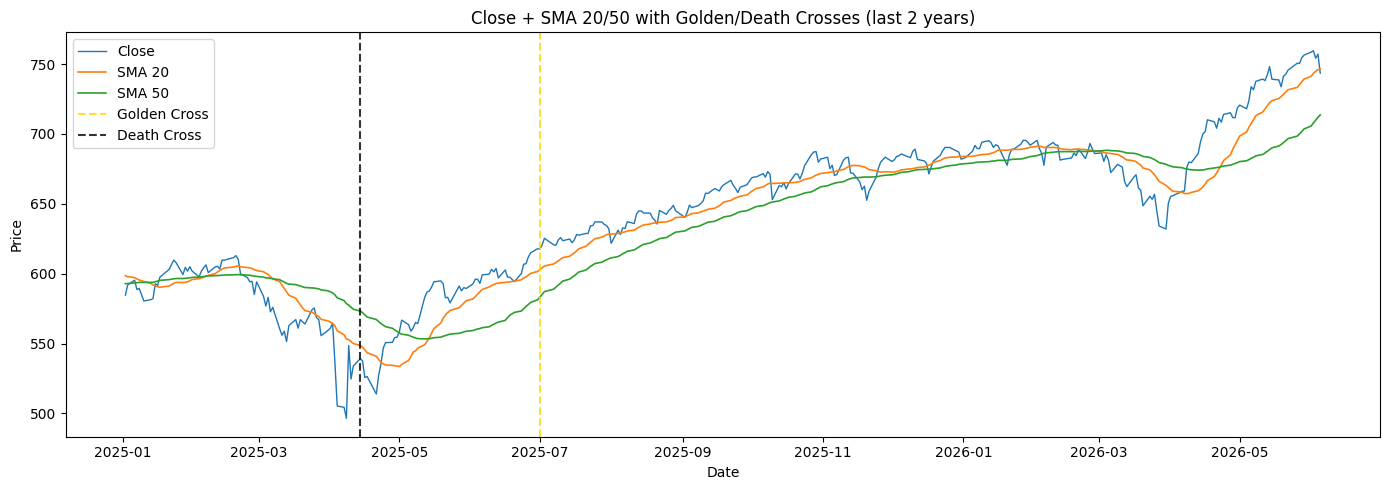

In [51]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.last('2Y')
cross  = np.sign(recent['sma_50'] - recent['sma_200']).diff().fillna(0)
golden = recent.index[cross > 0]
death  = recent.index[cross < 0]

# Plot Graph
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.index, recent['close'],  label='Close',  linewidth=1)
ax.plot(recent.index, recent['sma_20'], label='SMA 20', linewidth=1.2)
ax.plot(recent.index, recent['sma_50'], label='SMA 50', linewidth=1.2)

first_golden = True
for g in golden:
    ax.axvline(g, color='gold', linestyle='--', alpha=0.8,
               label='Golden Cross' if first_golden else '')
    first_golden = False

first_death = True
for d in death:
    ax.axvline(d, color='black', linestyle='--', alpha=0.8,
               label='Death Cross' if first_death else '')
    first_death = False

ax.legend()
ax.set_title('Close + SMA 20/50 with Golden/Death Crosses (last 2 years)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.tight_layout()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [52]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df['ema_12']       = close.ewm(span=12, adjust=False).mean()
df['ema_20']       = close.ewm(span=20, adjust=False).mean()
df['ema_26']       = close.ewm(span=26, adjust=False).mean()
df['ema_ratio_20'] = close / df['ema_20'] - 1

# df['ema_12']       = close.ewm(span=12, adjust=False).mean()
# df['ema_20']       = close.ewm(span=20, adjust=False).mean()
# df['ema_26']       = close.ewm(span=26, adjust=False).mean()
# df['ema_ratio_20'] = close / df['ema_20'] - 1

/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/2943174647.py:4: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')


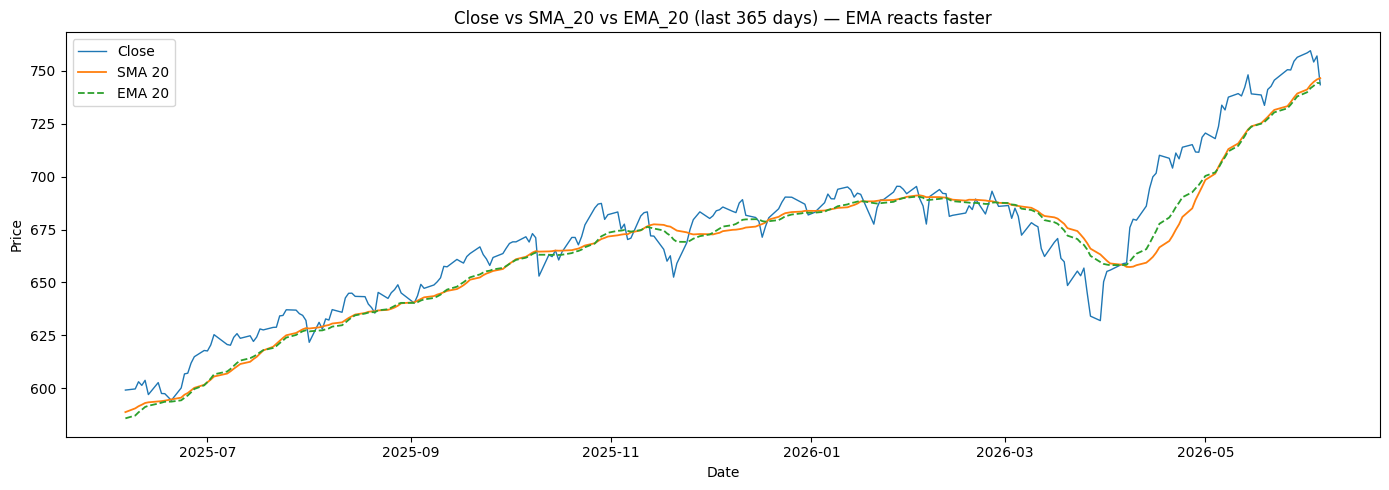

In [53]:

# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA

recent = df.last('365D')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.index, recent['close'],  label='Close',  linewidth=1)
ax.plot(recent.index, recent['sma_20'], label='SMA 20', linewidth=1.3)
ax.plot(recent.index, recent['ema_20'], label='EMA 20', linewidth=1.3, linestyle='--')
ax.legend()
ax.set_title('Close vs SMA_20 vs EMA_20 (last 365 days) — EMA reacts faster')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [54]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

n        = 14
delta    = close.diff()
gain     = delta.clip(lower=0)
loss     = (-delta).clip(lower=0)
avg_gain = gain.ewm(com=n - 1, adjust=False).mean()
avg_loss = loss.ewm(com=n - 1, adjust=False).mean()
rs       = avg_gain / avg_loss
df['rsi_14'] = (100 - 100 / (1 + rs)) / 100

# delta    = close.diff()
# gain     = delta.clip(lower=0)
# loss     = (-delta).clip(lower=0)
# avg_gain = gain.ewm(com=n - 1, adjust=False).mean()
# avg_loss = loss.ewm(com=n - 1, adjust=False).mean()
# rs       = avg_gain / avg_loss
# df['rsi_14'] = (100 - 100 / (1 + rs)) / 100

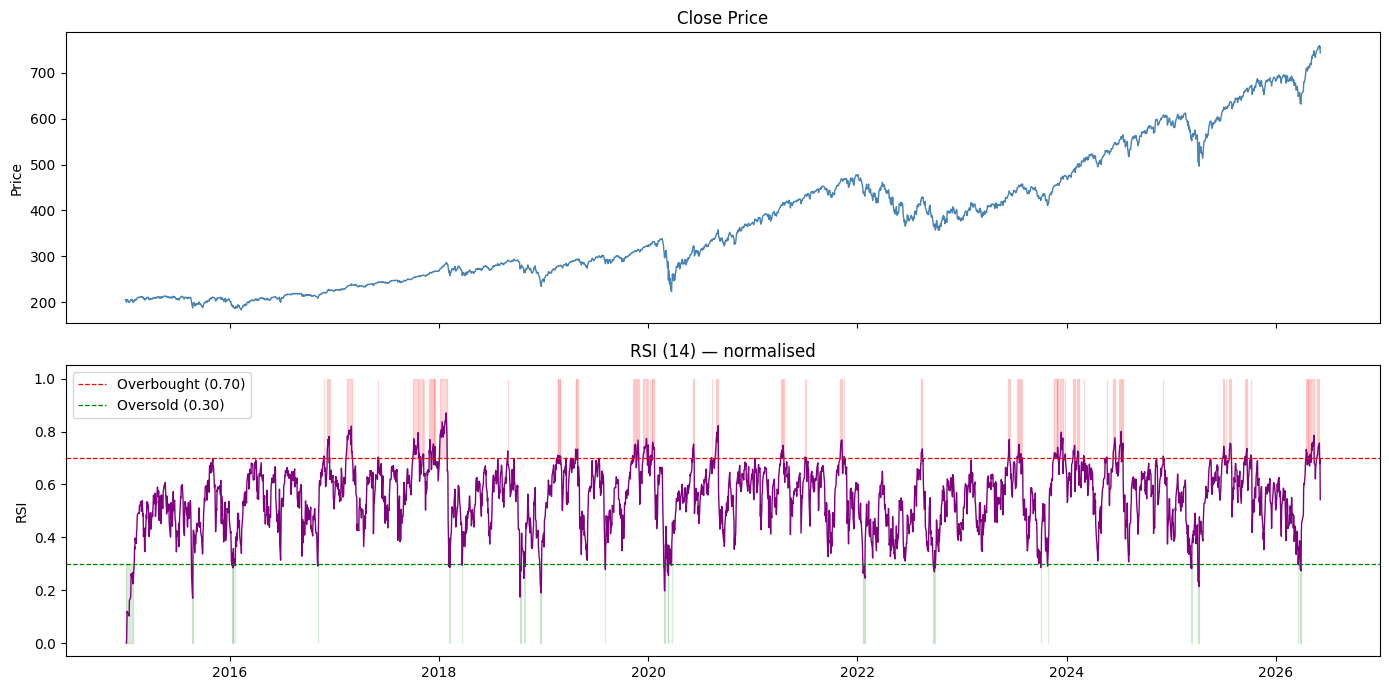

In [55]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df.index, df['close'], linewidth=1, color='steelblue')
ax1.set_title('Close Price')
ax1.set_ylabel('Price')

ax2.plot(df.index, df['rsi_14'], color='purple', linewidth=1)
ax2.axhline(0.70, linestyle='--', color='red',   linewidth=0.9, label='Overbought (0.70)')
ax2.axhline(0.30, linestyle='--', color='green', linewidth=0.9, label='Oversold (0.30)')
ax2.fill_between(df.index, 0.70, 1.0,  where=(df['rsi_14'] > 0.70), color='red',   alpha=0.15)
ax2.fill_between(df.index, 0.0,  0.30, where=(df['rsi_14'] < 0.30), color='green', alpha=0.15)
ax2.set_title('RSI (14) — normalised')
ax2.set_ylabel('RSI')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [56]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# df['macd']        = df['ema_12'] - df['ema_26']
# df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
# df['macd_hist']   = df['macd'] - df['macd_signal']

/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/3815412791.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('2Y')
/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/3815412791.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  recent = df.last('2Y')


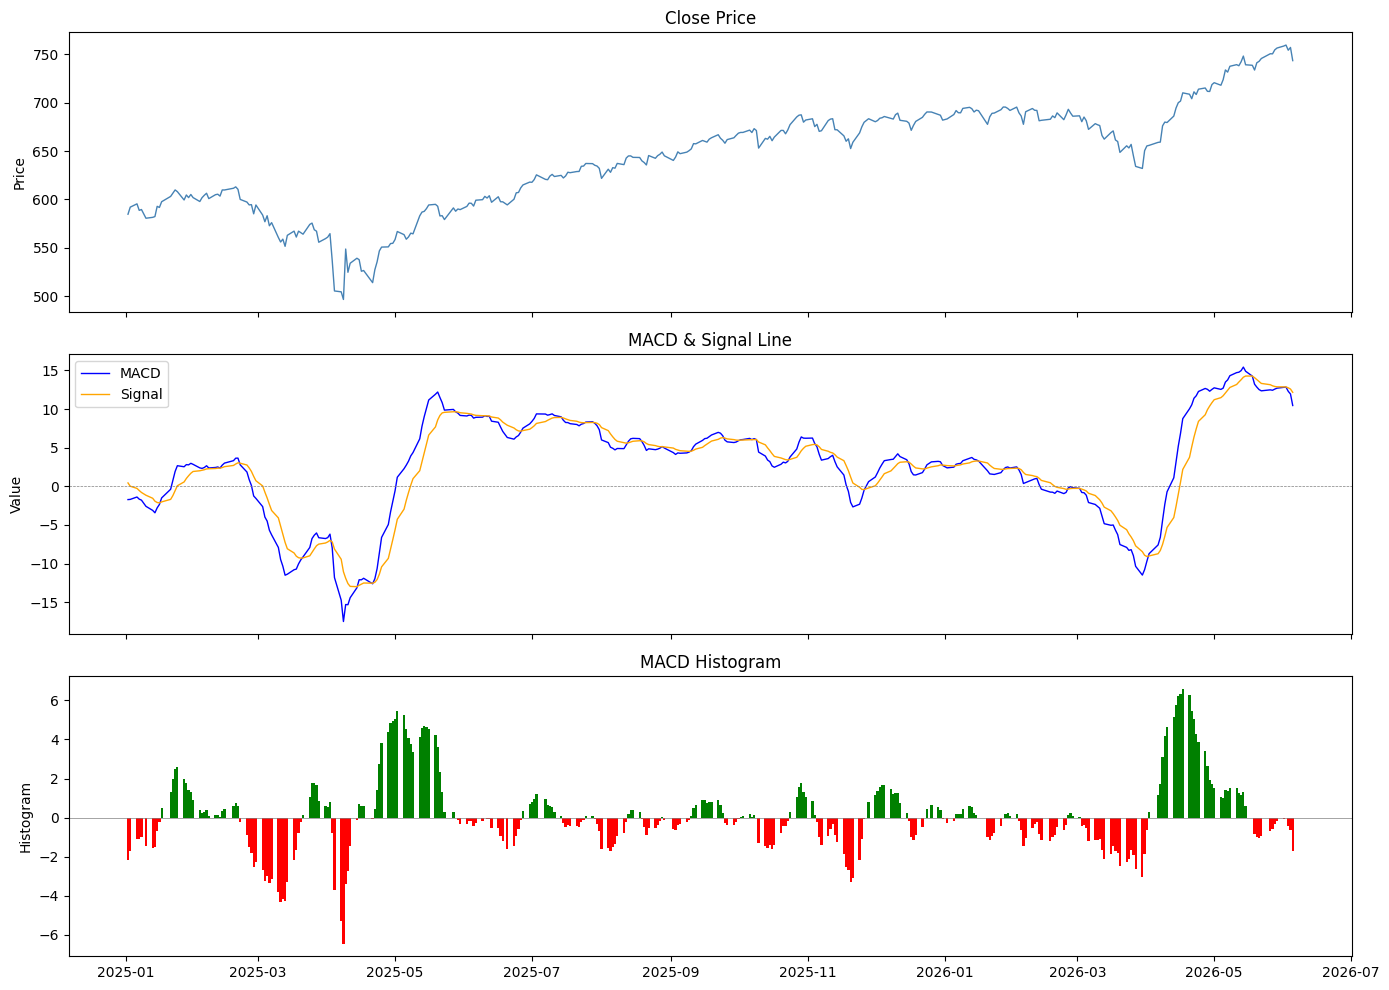

In [57]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign

recent = df.last('2Y')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(recent.index, recent['close'], linewidth=1, color='steelblue')
ax1.set_title('Close Price')
ax1.set_ylabel('Price')

ax2.plot(recent.index, recent['macd'],        label='MACD',   linewidth=1, color='blue')
ax2.plot(recent.index, recent['macd_signal'], label='Signal', linewidth=1, color='orange')
ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax2.legend()
ax2.set_title('MACD & Signal Line')
ax2.set_ylabel('Value')

colors = ['green' if v >= 0 else 'red' for v in recent['macd_hist']]
ax3.bar(recent.index, recent['macd_hist'], color=colors, width=1)
ax3.axhline(0, color='grey', linewidth=0.5)
ax3.set_title('MACD Histogram')
ax3.set_ylabel('Histogram')

plt.tight_layout()
plt.show()


## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [58]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = close.rolling(20).std()
df['bb_upper'] = df['sma_20'] + 2 * rolling_std
df['bb_lower'] = df['sma_20'] - 2 * rolling_std
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / close
df['bb_pct_b'] = ((close - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])).clip(0, 1)  # clip to [0, 1] optional but useful

# rolling_std    = close.rolling(20).std()
# df['bb_upper'] = df['sma_20'] + 2 * rolling_std
# df['bb_lower'] = df['sma_20'] - 2 * rolling_std
# df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / close
# df['bb_pct_b'] = ((close - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])).clip(0, 1)

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [59]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = (close - close.shift(5))  / close.shift(5)  * 100
df['roc_10'] = (close - close.shift(10)) / close.shift(10) * 100

# df['roc_5']  = (close - close.shift(5))  / close.shift(5)  * 100
# df['roc_10'] = (close - close.shift(10)) / close.shift(10) * 100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [60]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = close.shift(1)
true_range = pd.concat([
    high - low,
    (high - prev_close).abs(),
    (low  - prev_close).abs()
], axis=1).max(axis=1)
df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
df['atr_ratio'] = df['atr_14'] / close

# prev_close = close.shift(1)
# true_range = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
# df['atr_14']    = true_range.ewm(com=13, adjust=False).mean()
# df['atr_ratio'] = df['atr_14'] / close

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [61]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = low.rolling(14).min()
highest_high = high.rolling(14).max()
df['stoch_k'] = ((close - lowest_low) / (highest_high - lowest_low) * 100) / 100
df['stoch_d'] = df['stoch_k'].rolling(3).mean()

# lowest_low   = low.rolling(14).min()
# highest_high = high.rolling(14).max()
# df['stoch_k'] = ((close - lowest_low) / (highest_high - lowest_low) * 100) / 100
# df['stoch_d'] = df['stoch_k'].rolling(3).mean()

/var/folders/h_/mcnf18492nq8wcvkw9f8jkb00000gn/T/ipykernel_3796/2501276138.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('365D')


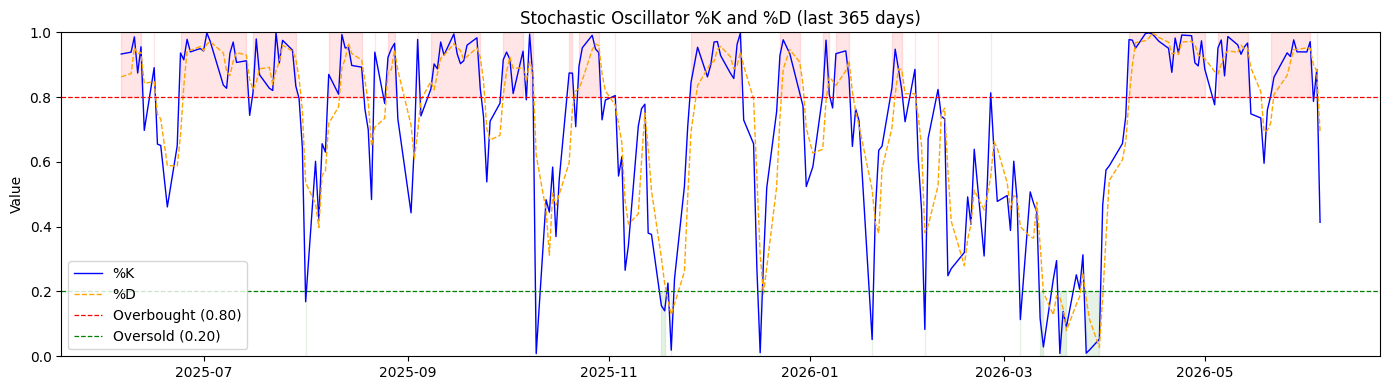

In [62]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal

recent = df.last('365D')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(recent.index, recent['stoch_k'], label='%K', linewidth=1, color='blue')
ax.plot(recent.index, recent['stoch_d'], label='%D', linewidth=1, color='orange', linestyle='--')
ax.axhline(0.80, linestyle='--', color='red',   linewidth=0.9, label='Overbought (0.80)')
ax.axhline(0.20, linestyle='--', color='green', linewidth=0.9, label='Oversold (0.20)')
ax.fill_between(recent.index, 0.80, 1.0,  where=(recent['stoch_k'] > 0.80), color='red',   alpha=0.1)
ax.fill_between(recent.index, 0.0,  0.20, where=(recent['stoch_k'] < 0.20), color='green', alpha=0.1)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Stochastic Oscillator %K and %D (last 365 days)')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()


## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [63]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction        = np.sign(close.diff())
df['obv']        = (direction * volume).fillna(0).cumsum()
df['obv_change'] = df['obv'].diff() / df['obv'].shift(1).abs()

# direction        = np.sign(close.diff())
# df['obv']        = (direction * volume).fillna(0).cumsum()
# df['obv_change'] = df['obv'].diff() / df['obv'].shift(1).abs()

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [64]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price    = (high + low + close) / 3
tp_vol           = typical_price * volume
df['vwap']       = tp_vol.rolling(20).sum() / volume.rolling(20).sum()
df['vwap_ratio'] = close / df['vwap'] - 1

# typical_price   = (high + low + close) / 3
# tp_vol          = typical_price * volume
# df['vwap']       = tp_vol.rolling(20).sum() / volume.rolling(20).sum()
# df['vwap_ratio'] = close / df['vwap'] - 1

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [65]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
    'future_return',
    'target_direction',
]

In [66]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = close.shift(-1) / close - 1
df['target_direction'] = (df['future_return'] > 0).astype(int)

required = FEATURE_COLUMNS
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df.dropna(subset=required).copy()
df_clean.reset_index(inplace=True)

out_path = PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
df_clean.to_csv(out_path, index=False)
print(f'Saved → {out_path}  |  shape: {df_clean.shape}')
df_clean[required].describe().round(4)

# df['future_return']    = close.shift(-1) / close - 1
# df['target_direction'] = (df['future_return'] > 0).astype(int)
# required = FEATURE_COLUMNS
# df       = df.replace([np.inf, -np.inf], np.nan)
# df_clean = df.dropna(subset=required).copy()
# out_path = PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
# df_clean.to_csv(out_path, index=False)
# print(f'Saved → {out_path}  |  shape: {df_clean.shape}')
# df_clean[required].describe().round(4)

Saved → data/processed/SPY_features.csv  |  shape: (2823, 40)


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000,2823.0000
mean,0.0005,0.0026,0.0005,0.0045,0.0113,0.0043,0.5570,1.2941,1.2773,0.2573,0.5075,0.0635,0.6074,0.0126,0.6548,0.6546,-0.0561,0.0068,0.0005,0.5469
std,0.0112,0.0229,0.0112,0.0249,0.0376,0.0211,0.1140,4.2068,3.9165,2.2915,3.1595,0.0464,0.2992,0.0067,0.3009,0.2780,3.1530,0.0241,0.0112,0.4979
min,-0.1094,-0.1797,-0.1159,-0.2008,-0.2782,-0.1784,0.1698,-23.7868,-19.8942,-17.9693,-23.2884,0.0097,0.0000,0.0037,0.0000,0.0138,-136.3902,-0.1815,-0.1094,0.0000
25%,-0.0037,-0.0073,-0.0037,-0.0058,-0.0046,-0.0044,0.4785,-0.3923,-0.3203,-0.7305,-0.8158,0.0366,0.3812,0.0085,0.4333,0.4376,-0.0827,-0.0039,-0.0037,0.0000
50%,0.0006,0.0040,0.0006,0.0082,0.0180,0.0082,0.5720,1.6383,1.6651,0.4035,0.7619,0.0526,0.6918,0.0107,0.7468,0.7475,0.0335,0.0094,0.0006,1.0000
75%,0.0059,0.0146,0.0059,0.0184,0.0346,0.0168,0.6407,3.6400,3.4368,1.4559,2.2580,0.0754,0.8503,0.0153,0.9207,0.9011,0.0905,0.0198,0.0059,1.0000
max,0.1050,0.1736,0.0999,0.1136,0.1325,0.0680,0.8703,15.4243,14.2691,17.3582,18.7979,0.5538,1.0000,0.0661,1.0000,0.9994,17.9637,0.1316,0.1050,1.0000


In [67]:
# TODO 11.2 (Challenge) — Run the full pipeline for atleast one downloaded symbols
# To process for all symbol change the symbol above rerun all cells to get features of that symbol.
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in RAW_DIR.glob('*.csv'):
    sym = csv_path.stem
    try:
        raw = pd.read_csv(csv_path, parse_dates=['date'], index_col='date')
        raw.sort_index(inplace=True)
        raw.columns = raw.columns.str.lower()
        raw.loc[raw['volume'] == 0, 'volume'] = np.nan
        rows_raw = len(raw)

        c, h, l, v = raw['close'], raw['high'], raw['low'], raw['volume']

        raw['return_1']     = c.pct_change(1)
        raw['return_5']     = c.pct_change(5)
        raw['log_return_1'] = np.log(c / c.shift(1))

        raw['sma_20']       = c.rolling(20).mean()
        raw['sma_50']       = c.rolling(50).mean()
        raw['sma_200']      = c.rolling(200).mean()
        raw['sma_ratio_20'] = c / raw['sma_20'] - 1
        raw['sma_ratio_50'] = c / raw['sma_50'] - 1

        raw['ema_12']       = c.ewm(span=12, adjust=False).mean()
        raw['ema_20']       = c.ewm(span=20, adjust=False).mean()
        raw['ema_26']       = c.ewm(span=26, adjust=False).mean()
        raw['ema_ratio_20'] = c / raw['ema_20'] - 1

        delta    = c.diff()
        gain     = delta.clip(lower=0)
        loss     = (-delta).clip(lower=0)
        raw['rsi_14'] = (100 - 100 / (1 + gain.ewm(com=13, adjust=False).mean() /
                                          loss.ewm(com=13, adjust=False).mean())) / 100

        raw['macd']        = raw['ema_12'] - raw['ema_26']
        raw['macd_signal'] = raw['macd'].ewm(span=9, adjust=False).mean()
        raw['macd_hist']   = raw['macd'] - raw['macd_signal']

        std20           = c.rolling(20).std()
        raw['bb_upper'] = raw['sma_20'] + 2 * std20
        raw['bb_lower'] = raw['sma_20'] - 2 * std20
        raw['bb_width'] = (raw['bb_upper'] - raw['bb_lower']) / c
        raw['bb_pct_b'] = ((c - raw['bb_lower']) / (raw['bb_upper'] - raw['bb_lower'])).clip(0, 1)

        raw['roc_5']  = (c - c.shift(5))  / c.shift(5)  * 100
        raw['roc_10'] = (c - c.shift(10)) / c.shift(10) * 100

        pc = c.shift(1)
        tr = pd.concat([(h - l), (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
        raw['atr_14']    = tr.ewm(com=13, adjust=False).mean()
        raw['atr_ratio'] = raw['atr_14'] / c

        ll = l.rolling(14).min()
        hh = h.rolling(14).max()
        raw['stoch_k'] = ((c - ll) / (hh - ll) * 100) / 100
        raw['stoch_d'] = raw['stoch_k'].rolling(3).mean()

        raw['obv']        = (np.sign(c.diff()) * v).fillna(0).cumsum()
        raw['obv_change'] = raw['obv'].diff() / raw['obv'].shift(1).abs()

        tp = (h + l + c) / 3
        raw['vwap']       = (tp * v).rolling(20).sum() / v.rolling(20).sum()
        raw['vwap_ratio'] = c / raw['vwap'] - 1

        raw['future_return']    = c.shift(-1) / c - 1
        raw['target_direction'] = (raw['future_return'] > 0).astype(int)

        raw.replace([np.inf, -np.inf], np.nan, inplace=True)
        processed = raw.dropna(subset=FEATURE_COLUMNS).reset_index()

        out = PROCESSED_DIR / f'{safe_symbol(sym)}_features.csv'
        processed.to_csv(out, index=False)

        drop_pct = round(100 * (1 - len(processed) / rows_raw), 2)
        summary.append({'symbol': sym, 'rows_raw': rows_raw,
                        'rows_processed': len(processed), 'drop_pct': drop_pct})
        print(f'✓ {sym:10s}  raw={rows_raw}  processed={len(processed)}  dropped={drop_pct}%')

    except Exception as e:
        print(f'✗ {sym}: {e}')
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

✓ INFY_NS     raw=2822  processed=2707  dropped=4.08%
✓ ETH_USD     raw=3131  processed=3081  dropped=1.6%
✓ TCS_NS      raw=2822  processed=2707  dropped=4.08%
✓ BTC_USD     raw=4174  processed=4124  dropped=1.2%
✓ MSFT        raw=2873  processed=2823  dropped=1.74%
✓ IXIC        raw=2873  processed=2823  dropped=1.74%
✓ NVDA        raw=2873  processed=2823  dropped=1.74%
✓ RELIANCE_NS  raw=2822  processed=2707  dropped=4.08%
✓ EURUSD_X    raw=2974  processed=0  dropped=100.0%
✓ TSLA        raw=2873  processed=2823  dropped=1.74%
✓ SPY         raw=2873  processed=2823  dropped=1.74%
✓ GSPC        raw=2873  processed=2803  dropped=2.44%
✓ JPY_X       raw=2974  processed=0  dropped=100.0%
✓ BSESN       raw=2810  processed=2638  dropped=6.12%
✓ AAPL        raw=2873  processed=2823  dropped=1.74%
✓ NSEI        raw=2811  processed=2351  dropped=16.36%


,symbol,rows_raw,rows_processed,drop_pct
0,INFY_NS,2822,2707,4.08
1,ETH_USD,3131,3081,1.60
2,TCS_NS,2822,2707,4.08
3,BTC_USD,4174,4124,1.20
4,MSFT,2873,2823,1.74
5,IXIC,2873,2823,1.74
6,NVDA,2873,2823,1.74
7,RELIANCE_NS,2822,2707,4.08
8,EURUSD_X,2974,0,100.00
9,TSLA,2873,2823,1.74


---
